In [1]:
import cv2
import time
import pandas as pd
import mediapipe as mp

hd = mp.solutions.hands
model = hd.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)

vid = cv2.VideoCapture(3)  
data = []
var = []
cap = False
sample = 0
c = 0

print("Started capturing... Press ESC to stop.")
print("Press 'n' to enter your variable")
while True:
    s, f = vid.read()
    if not s:
        break

    f = cv2.flip(f,1)
    rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    result = model.process(rgb)

    if result.multi_hand_landmarks:
        for i in result.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(f, i, hd.HAND_CONNECTIONS)

        if cap and sample < 1200:
            row = []
            for i in result.multi_hand_landmarks:
                for j in i.landmark:
                    row.extend([j.x, j.y, j.z])
            data.append(row)
            var.append(name)
            sample += 1
            cv2.putText(f, f"Capturing: {sample} /1200 of '{name}'.", (50, 100), cv2.FONT_HERSHEY_SCRIPT_COMPLEX, 1, (0, 255, 0), 2)

        elif sample == 1200:
            sample = 0
            cap = False
            c +=1
            print(f"{c} Captured 1200 samples for class '{name}'.")
            print()
            print("Press 'n' to enter your variable")
            name = ""

    cv2.imshow("koushik", f)

    key = cv2.waitKey(5) & 0xFF
    if key == 27:
        break
    elif key == ord("n"):
        name = input("Enter your class variable: ")
        print("Press 'c' to capture 1200 samples!")
    elif key == ord("c"):
        cap = True

vid.release()
cv2.destroyAllWindows()

df = pd.DataFrame(data)
df['label'] = var
df.to_csv("one_hand_data4444.csv", index=False)

Started capturing... Press ESC to stop.
Press 'n' to enter your variable


Enter your class variable:  E


Press 'c' to capture 1200 samples!
1 Captured 1200 samples for class 'E'.

Press 'n' to enter your variable


In [3]:
import pandas as pd

In [23]:
df = pd.read_csv("one_hand_data1111.csv")

In [5]:
df.duplicated().sum()

0

In [6]:
df["label"].value_counts()

label
A    2000
B    2000
C    2000
D    2000
Name: count, dtype: int64

In [7]:
import optuna
import sklearn
import matplotlib.pyplot as plt

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
from optuna.samplers import GridSampler

In [27]:
import numpy as np

In [28]:
fv = df.iloc[:,:-1]

In [29]:
cv = df.iloc[:,-1]

In [30]:
final_scaling = []
for i in fv.values:
    md = i.reshape(21,3)
    center = md - md[0]
    distance = np.linalg.norm(md[0]-md[12])
    fpd = center/(distance+1e-6)
    final_scaling.append(fpd.flatten())

In [31]:
fv = final_scaling

In [11]:
fv.shape, cv.shape

((8000, 63), (8000,))

In [12]:
pd.Series(cv).value_counts()

label
A    2000
B    2000
C    2000
D    2000
Name: count, dtype: int64

In [32]:
x_train, x_test, y_train, y_test = train_test_split(fv, cv, test_size=0.2, stratify=cv)

## standard 

In [22]:
std = StandardScaler()

In [111]:
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

In [48]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((46400, 63), (11600, 63), (46400,), (11600,))

In [49]:
pd.Series(y_test).value_counts()

label
Start        400
X            400
E            400
I            400
T            400
L            400
G            400
V            400
A            400
S            400
Backspace    400
Z            400
             400
D            400
O            400
Q            400
F            400
B            400
P            400
K            400
Y            400
W            400
C            400
H            400
U            400
N            400
R            400
M            400
J            400
Name: count, dtype: int64

In [44]:
dt = DecisionTreeClassifier()

In [45]:
model = dt.fit(x_train,y_train)

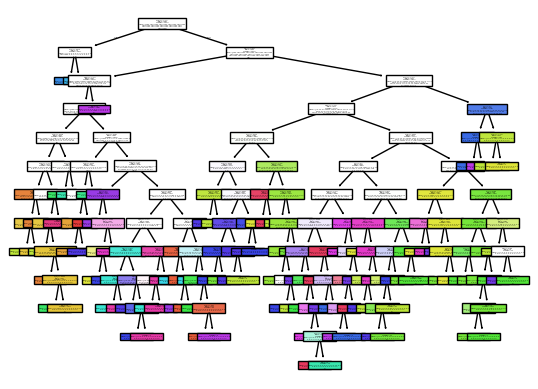

In [46]:
tree.plot_tree(model,filled = True)
plt.show()

## randomforest

In [33]:
def objective(trial):

    d1 = trial.suggest_int("d1",4,11)
    max_sample = trial.suggest_categorical("max_sample",[0.7, 0.8, 0.9])
    n = trial.suggest_int("n",4,20)
    
    model = RandomForestClassifier(n_estimators= n, max_depth = d1,  max_samples = max_sample)
    
    values = cross_validate(estimator = model, X = x_train, y=y_train, scoring="accuracy", cv=4,return_train_score=True,n_jobs=-1)
    
    train_ac = values["train_score"].mean()
    test_ac = values["test_score"].mean()
    trial.set_user_attr("train_ac",train_ac)
    return test_ac

In [34]:
space = {
    "d1": list(range(4,11)),
    "max_sample": [0.7, 0.8, 0.9],
    "n": list(range(4,20))
}
study = optuna.create_study(direction="maximize",sampler=GridSampler(search_space=space))
study.optimize(objective)

[I 2025-07-25 19:10:33,004] A new study created in memory with name: no-name-e06c2aa2-7f2d-497d-a77b-54953ee8ea60
[I 2025-07-25 19:10:41,316] Trial 0 finished with value: 0.99984375 and parameters: {'d1': 5, 'max_sample': 0.7, 'n': 10}. Best is trial 0 with value: 0.99984375.
[I 2025-07-25 19:10:48,345] Trial 1 finished with value: 0.9996875000000001 and parameters: {'d1': 5, 'max_sample': 0.7, 'n': 8}. Best is trial 0 with value: 0.99984375.
[I 2025-07-25 19:10:50,534] Trial 2 finished with value: 0.99984375 and parameters: {'d1': 9, 'max_sample': 0.9, 'n': 7}. Best is trial 0 with value: 0.99984375.
[I 2025-07-25 19:10:53,214] Trial 3 finished with value: 0.99984375 and parameters: {'d1': 9, 'max_sample': 0.8, 'n': 19}. Best is trial 0 with value: 0.99984375.
[I 2025-07-25 19:10:55,667] Trial 4 finished with value: 0.99984375 and parameters: {'d1': 8, 'max_sample': 0.7, 'n': 11}. Best is trial 0 with value: 0.99984375.
[I 2025-07-25 19:10:58,214] Trial 5 finished with value: 0.999843

KeyboardInterrupt: 

In [ ]:
{'d1': 10, 'max_sample': 0.8, 'n': 17} = 7
{'d1': 10, 'max_sample': 0.9, 'n': 19} = 17
{'d1': 10, 'max_sample': 0.7, 'n': 15} = 34

In [68]:
study.best_value

0.9998706896551723

In [69]:
study.best_params

{'d1': 10, 'max_sample': 0.7, 'n': 15}

In [70]:
study.best_trial

FrozenTrial(number=34, state=1, values=[0.9998706896551723], datetime_start=datetime.datetime(2025, 7, 24, 16, 18, 58, 280621), datetime_complete=datetime.datetime(2025, 7, 24, 16, 19, 3, 958681), params={'d1': 10, 'max_sample': 0.7, 'n': 15}, user_attrs={'train_ac': 0.9999353448275862}, system_attrs={'search_space': {'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [0.7, 0.8, 0.9], 'n': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]}, 'grid_id': 34}, intermediate_values={}, distributions={'d1': IntDistribution(high=11, log=False, low=4, step=1), 'max_sample': CategoricalDistribution(choices=(0.7, 0.8, 0.9)), 'n': IntDistribution(high=20, log=False, low=4, step=1)}, trial_id=34, value=None)

In [71]:
df1 = study.trials_dataframe()

In [72]:
df1

,number,value,datetime_start,datetime_complete,duration,params_d1,params_max_sample,params_n,user_attrs_train_ac,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.868491,2025-07-24 16:16:32.314252,2025-07-24 16:16:37.924159,0 days 00:00:05.609907,5,0.7,10,0.869432,0,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
1,1,0.851789,2025-07-24 16:16:37.927263,2025-07-24 16:16:42.181697,0 days 00:00:04.254434,5,0.7,8,0.853506,1,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
2,2,0.995539,2025-07-24 16:16:42.182697,2025-07-24 16:16:45.210722,0 days 00:00:03.028025,9,0.9,7,0.995999,2,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
3,3,0.997996,2025-07-24 16:16:45.213674,2025-07-24 16:16:52.022171,0 days 00:00:06.808497,9,0.8,19,0.998226,3,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
4,4,0.993793,2025-07-24 16:16:52.023173,2025-07-24 16:16:55.629515,0 days 00:00:03.606342,8,0.7,11,0.994095,4,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...
331,331,0.998707,2025-07-24 16:37:24.993961,2025-07-24 16:37:28.210088,0 days 00:00:03.216127,10,0.9,7,0.998994,331,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
332,332,0.984116,2025-07-24 16:37:28.211089,2025-07-24 16:37:30.013821,0 days 00:00:01.802732,8,0.7,4,0.986494,332,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
333,333,0.937845,2025-07-24 16:37:30.014824,2025-07-24 16:37:33.098265,0 days 00:00:03.083441,6,0.8,9,0.938534,333,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE
334,334,0.877112,2025-07-24 16:37:33.099277,2025-07-24 16:37:37.586676,0 days 00:00:04.487399,4,0.9,19,0.879260,334,"{'d1': [4, 5, 6, 7, 8, 9, 10], 'max_sample': [...",COMPLETE


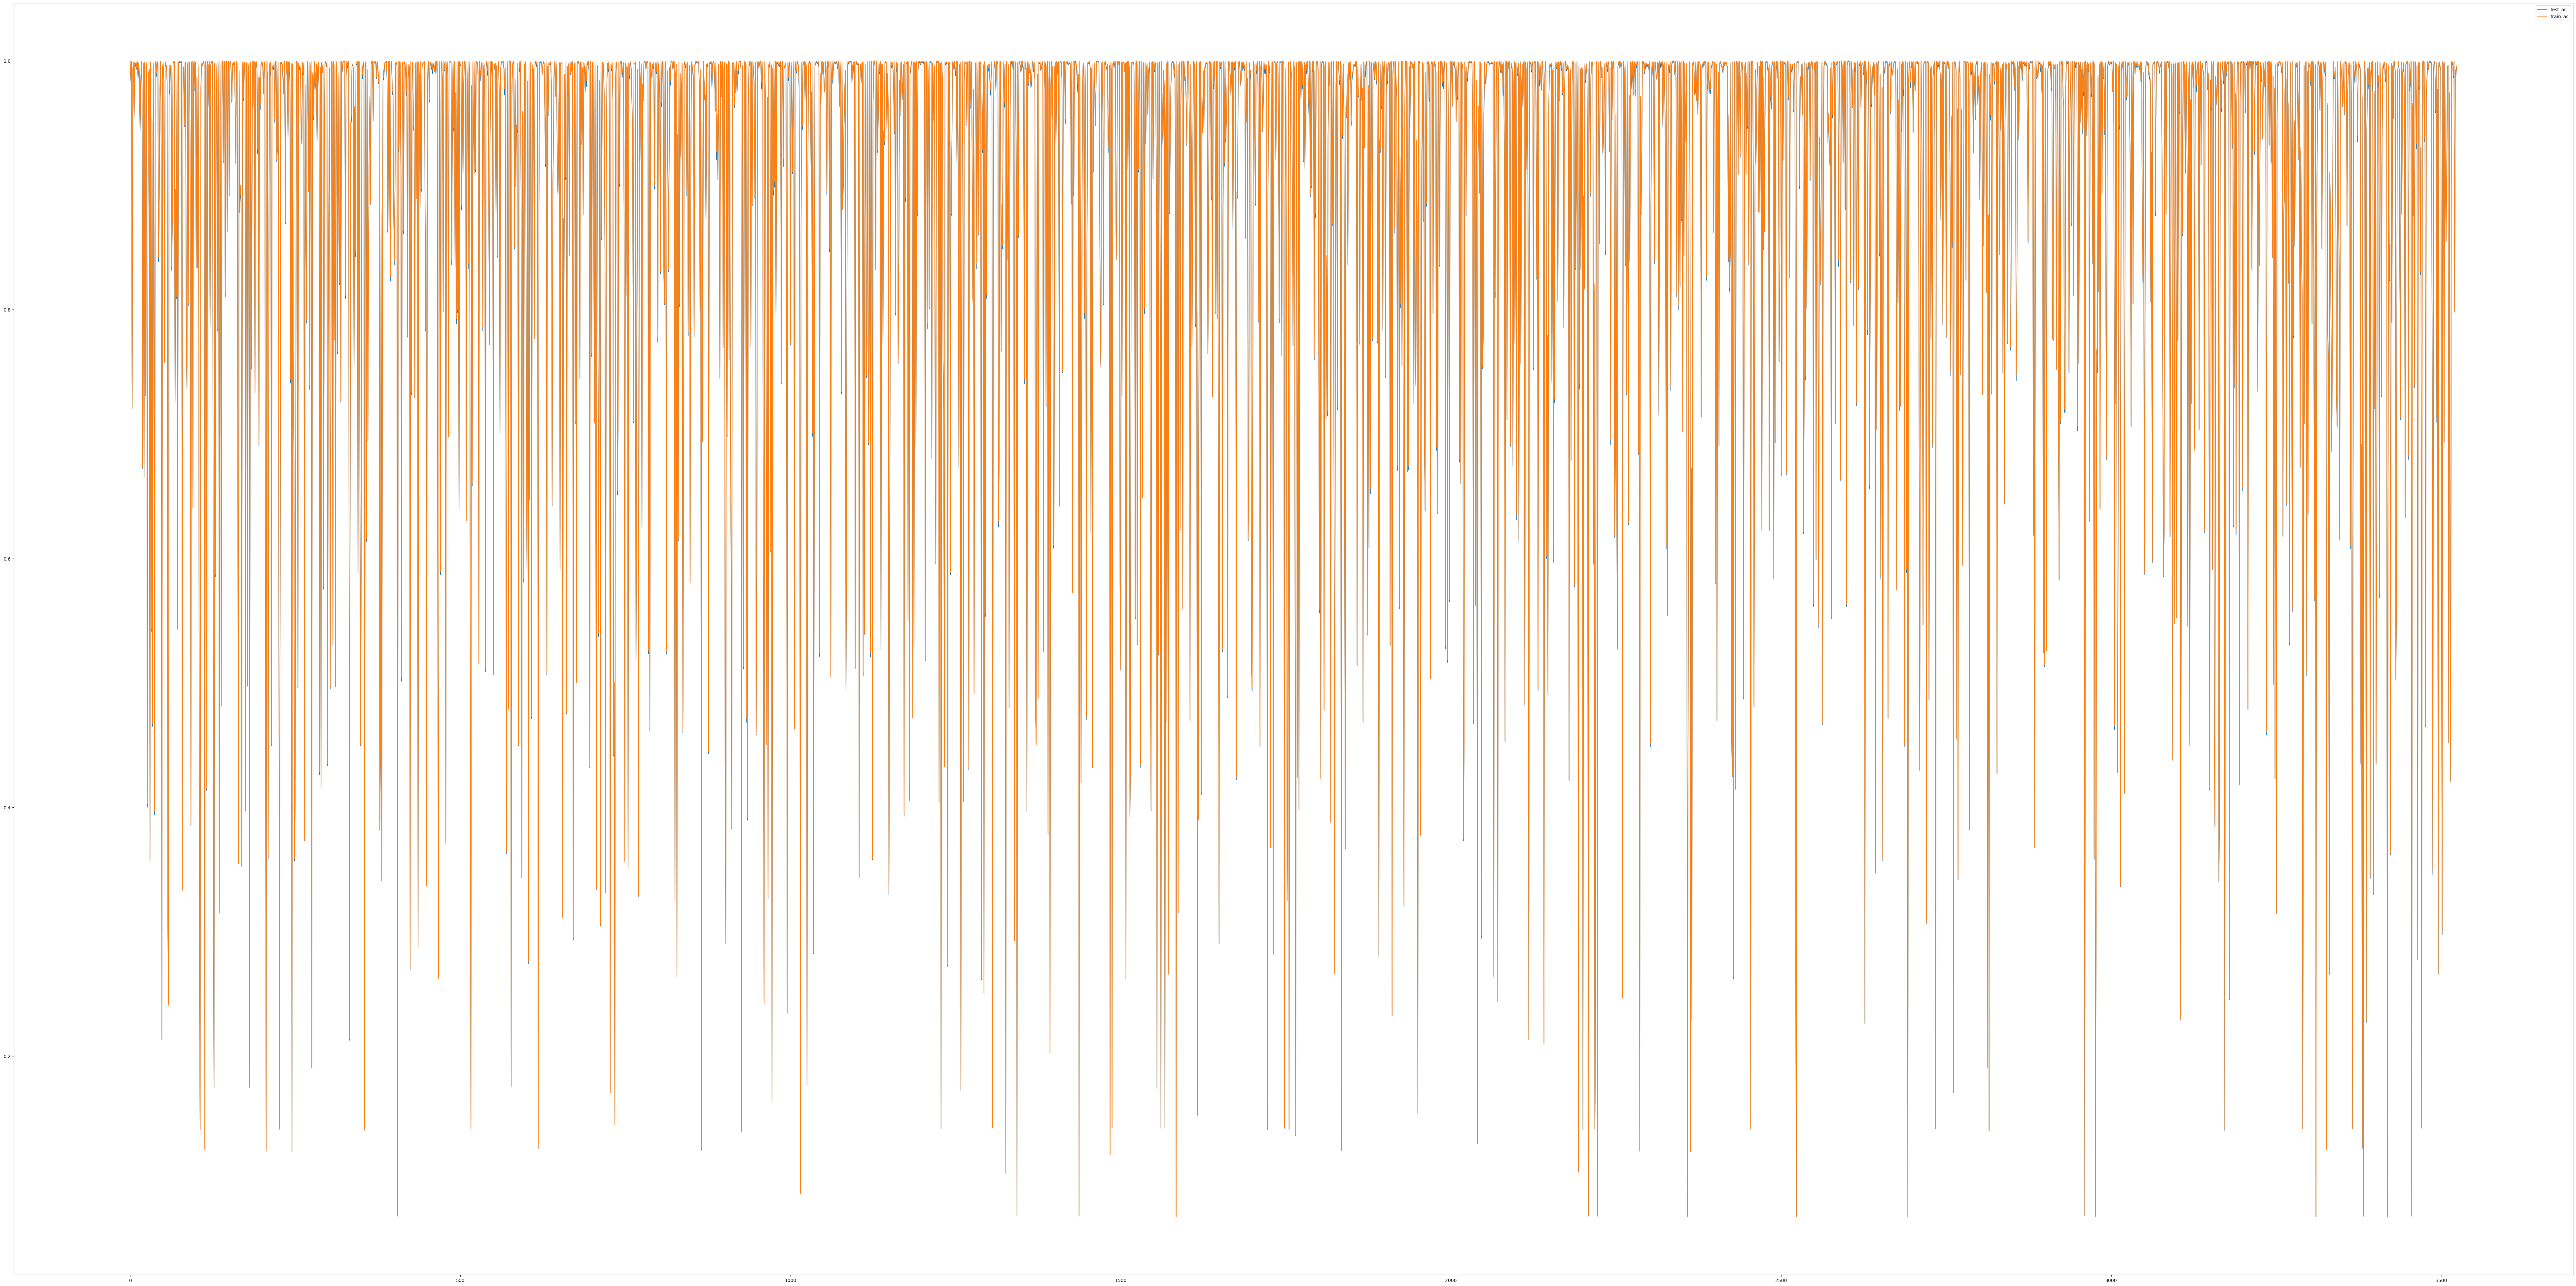

In [77]:
plt.figure(figsize=(100,50))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="test_ac")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_train_ac"],label="train_ac")
plt.legend()
plt.show()

## Best Trails 

In [ ]:
{'d1': 10, 'max_sample': 0.8, 'n': 17} = 7
{'d1': 10, 'max_sample': 0.9, 'n': 19} = 17
{'d1': 10, 'max_sample': 0.7, 'n': 15} = 34

In [83]:
x_train, x_test, y_train, y_test = train_test_split(fv, cv, test_size=0.2, stratify=cv)

In [35]:
rfc = RandomForestClassifier(n_estimators=10,max_depth=5,max_samples=0.7)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

1.0

In [80]:
rfc = RandomForestClassifier(n_estimators=19,max_depth=10,max_samples=0.9)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

0.9999137931034483

In [82]:
rfc = RandomForestClassifier(n_estimators=15,max_depth=10,max_samples=0.7)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

0.9996551724137931

In [84]:
rfc = RandomForestClassifier(n_estimators=17,max_depth=10,max_samples=0.8)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

0.9994827586206897

In [17]:
model

RandomForestClassifier(max_depth=5, max_samples=0.7, n_estimators=10)

In [18]:
import pickle

In [89]:
with open("randomforest_hands.plk", "wb") as f:
    pickle.dump((model,x_train.columns), f)

In [90]:
with open("randomforest_hands.plk", "rb") as f:
    rf,f = pickle.load(f)

In [36]:
with open("handModelSurya.plk", "wb") as f:
    pickle.dump(model, f)

## hand code starts from here

In [37]:
import cv2
import time
import pickle
import pandas as pd
import mediapipe as mp

hd = mp.solutions.hands
model1 = hd.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)
with open("randomforest_hands.plk", "rb") as f:
    model = pickle.load(f)
    
vid = cv2.VideoCapture(3)  
st =''
while True:
    s, f = vid.read()
    
    if s:
        rgb = f[:,:,::-1]
        result = model1.process(rgb)
        if result.multi_hand_landmarks:
            row = []
            for i in result.multi_hand_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(f, i, hd.HAND_CONNECTIONS)    
                for j in i.landmark:
                    row.extend([j.x, j.y, j.z])
                com = list(range(0,63))
                input_df = pd.DataFrame([row], columns=fea)
                pre = model.predict(input_df)[0]
                if pre == "Backspace":
                    st = st[:-1]
                else:
                    st = st + pre
                cv2.putText(f,f"Predicted : {st}",(50,120),cv2.FONT_HERSHEY_COMPLEX,1,(0,255,0),2)
                cv2.putText(f,f"Predicted : {pre}",(50,150),cv2.FONT_HERSHEY_COMPLEX,1,(0,255,0),2) 
    
        cv2.imshow("koushik", f)
        key = cv2.waitKey(1) & 0xFF
        if key == 27:
            break
    else:
        break

vid.release()
cv2.destroyAllWindows()

NameError: name 'fea' is not defined

In [20]:
import cv2
import time
import pickle
import pandas as pd
import mediapipe as mp

# MediaPipe Hands setup
hd = mp.solutions.hands
model1 = hd.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)

# Load the trained model and feature columns
with open("randomforest_hands.plk", "rb") as f:
    rfc, fea = pickle.load(f)

# Start video capture
vid = cv2.VideoCapture(3)

# String to store typed letters
st = ''

# Timing variables
last_prediction_time = 0
prediction_delay = 2  # seconds

while True:
    success, frame = vid.read()
    
    if not success:
        break
    frame = cv2.flip(frame,1)
    rgb = frame[:, :, ::-1]  # BGR to RGB
    result = model1.process(rgb)

    if result.multi_hand_landmarks:
        row = []
        for hand in result.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(frame, hand, hd.HAND_CONNECTIONS)
            for lm in hand.landmark:
                row.extend([lm.x, lm.y, lm.z])
        
        if len(row) == 63:
            input_df = pd.DataFrame([row], columns=fea)
            
            current_time = time.time()
            if current_time - last_prediction_time >= prediction_delay:
                pre = rfc.predict(input_df)[0]
                if pre == "Backspace":
                    st = st[:-1]
                else:
                    st = st + pre

                last_prediction_time = current_time  # reset timer

                # Show predicted character
                cv2.putText(frame, f"Predicted Char: {pre}", (50, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 0), 2)

    # Show full typed string
    cv2.putText(frame, f"Typed Text: {st}", (50, 120), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("Koushik", frame)

    if cv2.waitKey(1) & 0xFF == 27: 
        break

vid.release()
cv2.destroyAllWindows()
